# Exploratory Data Analysis

**Цель:** Провести глубокий анализ датасета перед обучением модели тональности для
системы мониторинга качества товаров в реальном времени



---



## Импорты

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import json
from pathlib import Path
from collections import Counter

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud, STOPWORDS

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mutual_info_score

# Config
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
RANDOM_STATE = 42
SAVE_DIR = Path("plots")
SAVE_DIR.mkdir(exist_ok=True)



---



## Загрузка данных

In [2]:
from huggingface_hub import hf_hub_download

REPO_ID = "McAuley-Lab/Amazon-Reviews-2023"

# Отзывы
LOCAL_REVIEWS_PATH = hf_hub_download(
    repo_id=REPO_ID,
    filename="raw/review_categories/All_Beauty.jsonl",
    repo_type="dataset"
)

# Метаданные товаров
LOCAL_META_PATH = hf_hub_download(
    repo_id=REPO_ID,
    filename="raw/meta_categories/meta_All_Beauty.jsonl",
    repo_type="dataset"
)

print(f"Reviews:  {LOCAL_REVIEWS_PATH}")
print(f"Metadata: {LOCAL_META_PATH}")

raw/review_categories/All_Beauty.jsonl:   0%|          | 0.00/327M [00:00<?, ?B/s]

raw/meta_categories/meta_All_Beauty.json(…):   0%|          | 0.00/213M [00:00<?, ?B/s]

Reviews:  /root/.cache/huggingface/hub/datasets--McAuley-Lab--Amazon-Reviews-2023/snapshots/2b6d039ed471f2ba5fd2acb718bf33b0a7e5598e/raw/review_categories/All_Beauty.jsonl
Metadata: /root/.cache/huggingface/hub/datasets--McAuley-Lab--Amazon-Reviews-2023/snapshots/2b6d039ed471f2ba5fd2acb718bf33b0a7e5598e/raw/meta_categories/meta_All_Beauty.jsonl


In [3]:
PARQUET_PATH = "all_beauty_raw.parquet"
META_PARQUET  = "all_beauty_meta.parquet"

REVIEW_FIELDS = [
    "rating", "title", "text", "timestamp",
    "verified_purchase", "helpful_vote",
    "asin", "parent_asin", "user_id"
]

META_FIELDS = [
    "parent_asin", "title", "average_rating",
    "rating_number", "price", "store"
]

if Path(PARQUET_PATH).exists():
    df = pd.read_parquet(PARQUET_PATH)
    print(f"Reviews loaded from cache: {df.shape}")
else:
    df = pd.read_json(LOCAL_REVIEWS_PATH, lines=True)
    df = df[[c for c in REVIEW_FIELDS if c in df.columns]]
    df.to_parquet(PARQUET_PATH, index=False)
    print(f"Reviews saved to {PARQUET_PATH}: {df.shape}")

if Path(META_PARQUET).exists():
    df_meta = pd.read_parquet(META_PARQUET)
    print(f"Meta loaded from cache: {df_meta.shape}")
else:
    df_meta = pd.read_json(LOCAL_META_PATH, lines=True)
    df_meta = df_meta[[c for c in META_FIELDS if c in df_meta.columns]]
    df_meta = df_meta.drop_duplicates(subset=["parent_asin"])
    df_meta.to_parquet(META_PARQUET, index=False)
    print(f"Meta saved to {META_PARQUET}: {df_meta.shape}")

print(f"\nShape reviews:  {df.shape[0]:,} rows {df.shape[1]} cols")
print(f"Shape metadata: {df_meta.shape[0]:,} rows {df_meta.shape[1]} cols")
df.head(3)

Reviews saved to all_beauty_raw.parquet: (701528, 9)
Meta saved to all_beauty_meta.parquet: (112590, 6)

Shape reviews:  701,528 rows 9 cols
Shape metadata: 112,590 rows 6 cols


,rating,title,text,timestamp,verified_purchase,helpful_vote,asin,parent_asin,user_id
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,2020-05-05 14:08:48.923,True,0,B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",2020-05-04 18:10:55.070,True,1,B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ
2,5,Yes!,"Smells good, feels great!",2020-05-16 21:41:06.052,True,2,B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ


In [ ]:
df_meta = df_meta.rename(columns={"title": "product_title"})

df = df.merge(
    df_meta[["parent_asin", "product_title", "price"]],
    on="parent_asin",
    how="left"
)

print(f"After join: {df.shape}")
print(f"Products matched: {df['product_title'].notna().mean()*100:.1f}%")
df[["rating", "text", "product_title", "price"]].head(3)

After join: (701528, 11)
Products matched: 100.0%


,rating,text,product_title,price
0,5,This spray is really nice. It smells really go...,Herbivore - Natural Sea Mist Texturizing Salt ...,NaN
1,4,"This product does what I need it to do, I just...",All Natural Vegan Dry Shampoo Powder - Eco Fri...,NaN
2,5,"Smells good, feels great!",New Road Beauty - Creamsicle - Variety 3 Pack ...,21.9800


In [ ]:
df["dt"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=False)

df["rating"]            = pd.to_numeric(df["rating"],         errors="coerce")
df["helpful_vote"]      = pd.to_numeric(df["helpful_vote"],   errors="coerce").fillna(0).astype(int)
df["verified_purchase"] = df["verified_purchase"].astype(bool)
df["text"]              = df["text"].fillna("")
df["title"]             = df["title"].fillna("")

# Фильтрация dt
print(f"dt dtype:  {df['dt'].dtype}")
print(f"dt sample: {df['dt'].dropna().sample(3, random_state=42).tolist()}")
print(f"dt min:    {df['dt'].min()}")
print(f"dt max:    {df['dt'].max()}")

MIN_DT = pd.Timestamp("1996-05-01")
MAX_DT = pd.Timestamp("2023-12-31")

n_invalid = ((df["dt"] < MIN_DT) | (df["dt"] > MAX_DT) | df["dt"].isna()).sum()
print(f"\nInvalid timestamps: {n_invalid:,} ({n_invalid / len(df) * 100:.3f}%)")

df = df[(df["dt"] >= MIN_DT) & (df["dt"] <= MAX_DT)].copy()

# Дропаем строки без рейтинга/даты/текста
before = len(df)
df = df.dropna(subset=["rating", "dt"])
df = df[df["text"].str.len() >= 3]
df = df[(df["rating"] >= 1) & (df["rating"] <= 5)]

print(f"Dropped {before - len(df):,} rows ({(before - len(df)) / before * 100:.1f}%)")
print(f"Final shape: {df.shape}")
print(f"Rating unique values: {sorted(df['rating'].unique())}")
print(f"Timestamp range: start at {df['dt'].min().date()} end at {df['dt'].max().date()}")

df = df.drop(columns=["timestamp"])

dt dtype:  datetime64[ns]
dt sample: [Timestamp('2015-05-09 22:04:41'), Timestamp('2017-06-01 01:04:59'), Timestamp('2019-06-24 16:14:04.340000')]
dt min:    2000-11-01 04:24:18
dt max:    2023-09-09 00:39:36.666000

Invalid timestamps: 0 (0.000%)
Dropped 2,354 rows (0.3%)
Final shape: (699174, 12)
Rating unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Timestamp range: start at 2000-11-01 end at 2023-09-09


Итоговый датасет содержит 699,174 строк и 12 признаков

Потери при очистке составили только 0.3% — абсолютный минимум. Отброшены только строки с `NaN` в `rating`/`dt` и тексты длиной < 3 символа

При этом данные покрывают отзывы, начиная с 2000 и заканчивая 2023 годом



---



## Анализ данных

**Анализ целевой переменной**

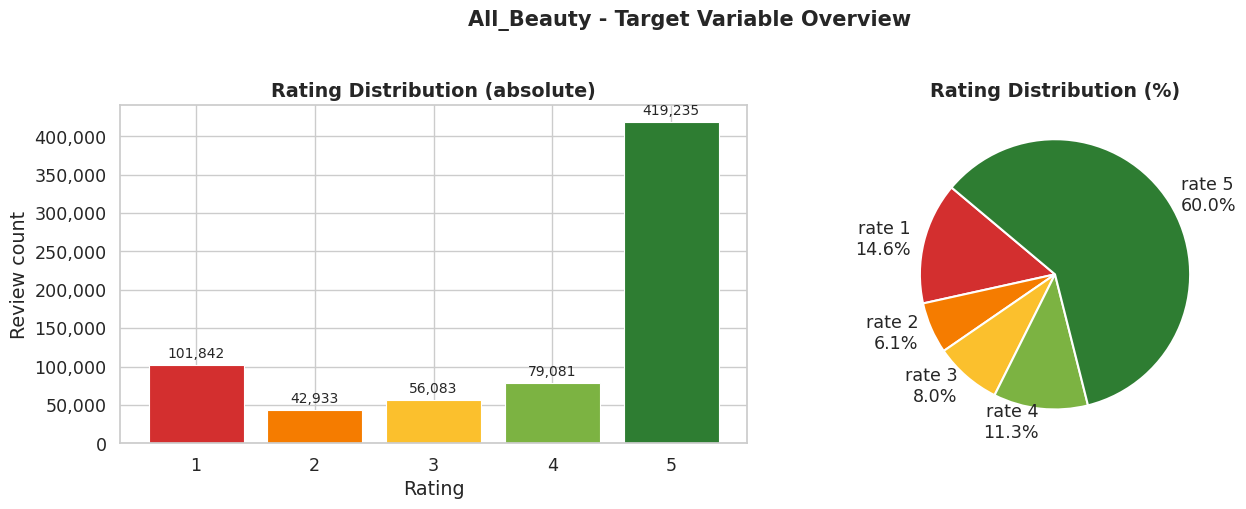

         count  pct (%)
rating                 
1       101842  14.6000
2        42933   6.1000
3        56083   8.0000
4        79081  11.3000
5       419235  60.0000


In [ ]:
# Дистрибуция рейтингов
rating_counts = df["rating"].value_counts().sort_index()
rating_pct    = (rating_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Абсолютные значения
colors = ["#d32f2f", "#f57c00", "#fbc02d", "#7cb342", "#2e7d32"]
bars = axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Rating Distribution (absolute)", fontweight="bold")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Review count")
axes[0].bar_label(bars, labels=[f"{v:,}" for v in rating_counts.values], padding=3, fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Процентный пирог
wedge_colors = ["#d32f2f", "#f57c00", "#fbc02d", "#7cb342", "#2e7d32"]
axes[1].pie(
    rating_counts.values,
    labels=[f"rate {int(r)}\n{p}%" for r, p in zip(rating_counts.index, rating_pct.values)],
    colors=wedge_colors, autopct="",
    startangle=140, pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Rating Distribution (%)", fontweight="bold")

plt.suptitle("All_Beauty - Target Variable Overview", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Таблица
print(pd.DataFrame({"count": rating_counts, "pct (%)": rating_pct}))


График демонстрирует классическое **J-shaped распределение**,
характерное для отзывов на e-commerce платформах.
Кривая стартует относительно высоко на 1, резко падает к 2,
после чего монотонно растет до доминирующего пика на 5:
Это объясняется **purchase motivation bias**: покупатели,
оставляющие отзыв, делятся на два лагеря - "хочу порекомендовать" (5) и "хочу предупредить" (1). Нейтральный опыт (2–4) редко мотивирует к написанию отзыва

Стратегия разметки: от 5 классов к бинарным меткам

Перед обучением необходимо преобразовать шкалу рейтингов
в дискретные метки. Рассматриваем промежуточный шаг - 3-классовую разметку - чтобы количественно обосновать решение об исключении нейтрального класса

**Гипотеза:** нейтральные отзывы (3) несут смешанный текстовый сигнал
и ухудшают границу решения модели => их следует исключить из обучения

In [ ]:
# Class imbalance
label_map = {1.0: "negative", 2.0: "negative", 3.0: "neutral",
             4.0: "positive", 5.0: "positive"}
df["sentiment_3class"] = df["rating"].map(label_map)

counts_3 = df["sentiment_3class"].value_counts()
imbalance_ratio = counts_3["positive"] / counts_3["negative"]

print("3-class label distribution:")
print(counts_3.to_frame("count").assign(pct=lambda x: (x["count"]/len(df)*100).round(1)))
print(f"\nImbalance ratio (pos/neg): {imbalance_ratio:.1f}x")

3-class label distribution:
                   count     pct
sentiment_3class                
positive          498316 71.3000
negative          144775 20.7000
neutral            56083  8.0000

Imbalance ratio (pos/neg): 3.4x


Почему будем дрропать 3 (нейтральный класс):

3 - это не отдельная тональность, а зона неопределенности.
Типичные тексты: *"It's okay, nothing special"*, *"Average, does the job"*
Такие тексты содержат одновременно позитивные и негативные сигналы,
и модель не может надежно отличить их ни от одного класса.
Включение 3 в negative или positive добавляет **label noise**
и снижает F1 на обоих классах.

При этом стоит отметить, что 3.4x - управляемый дисбаланс. При соотношении <=5:1 достаточно
`WeightedCrossEntropyLoss` без агрессивного oversampling.
При >=10:1 потребовался бы SMOTE или полный resampling



---



**Временной анализ**

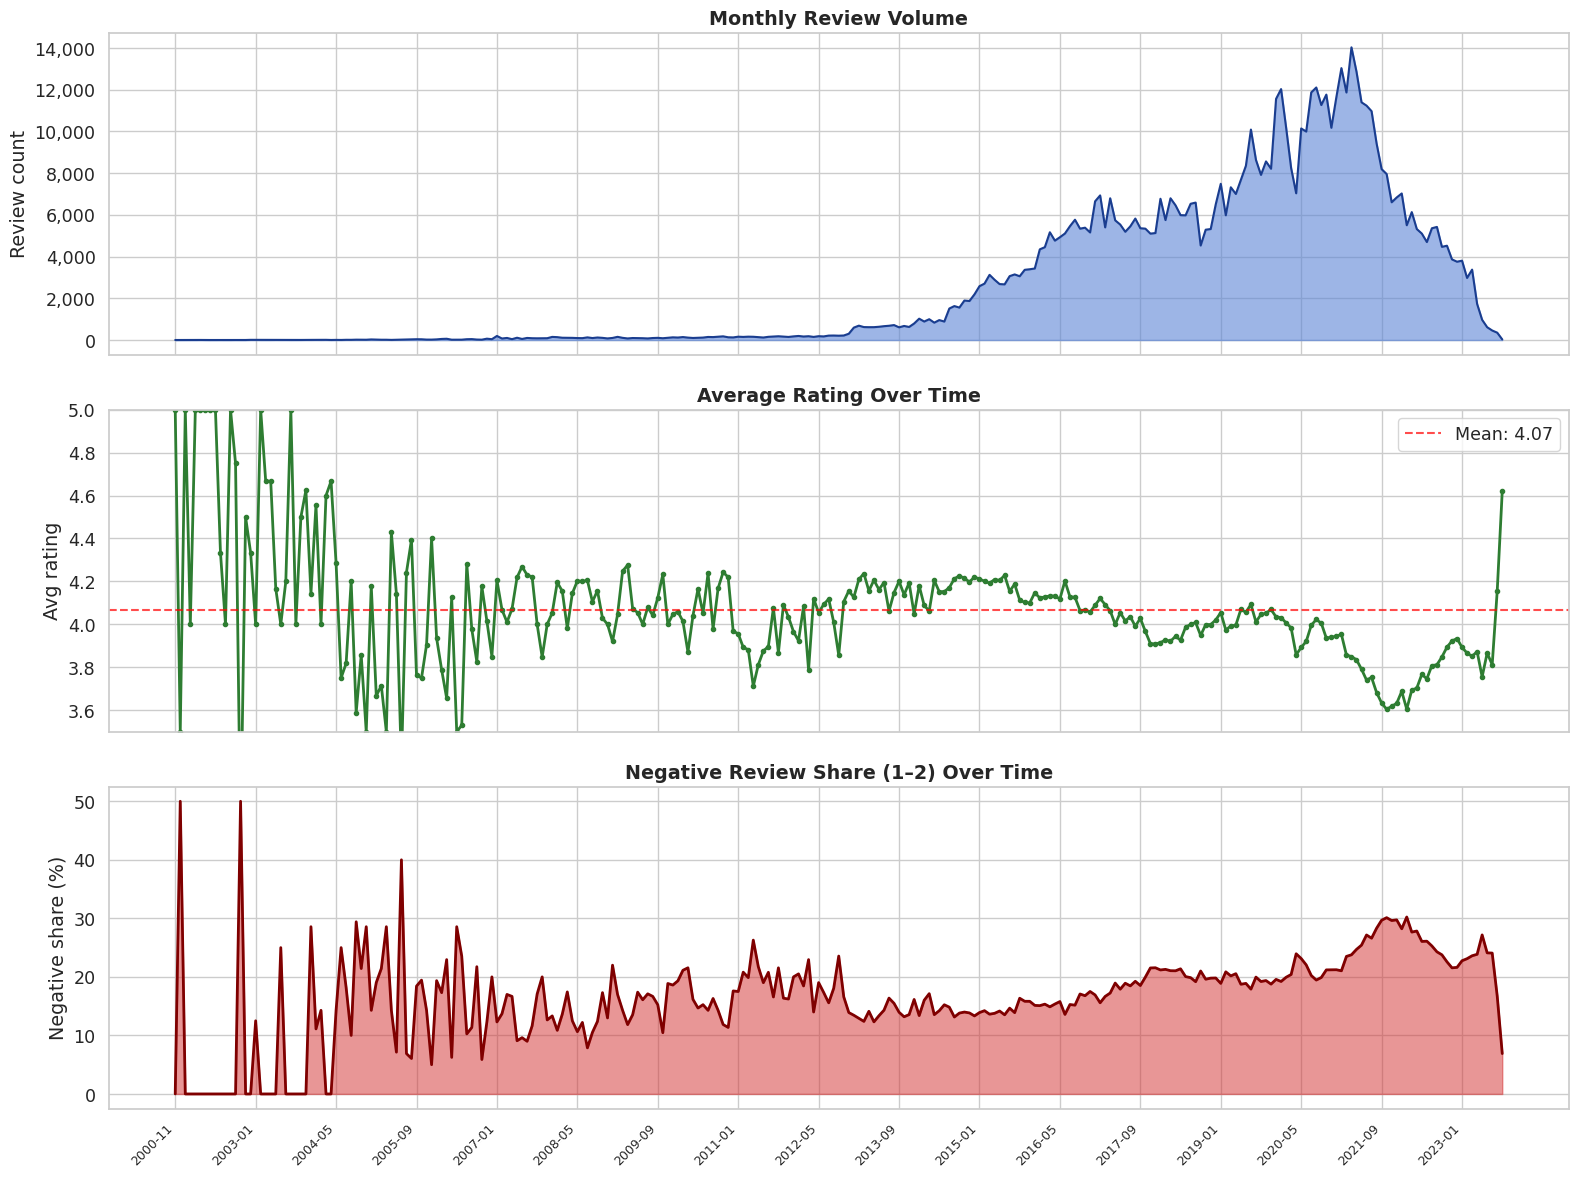

In [ ]:
df["year"]       = df["dt"].dt.year
df["month"]      = df["dt"].dt.month
df["year_month"] = df["dt"].dt.to_period("M")
df["day_of_week"]= df["dt"].dt.dayofweek

# Объем отзывов + средний рейтинг по месяцам
monthly = df.groupby("year_month").agg(
    review_count=("rating", "count"),
    avg_rating=("rating", "mean"),
    neg_share=("rating", lambda x: (x <= 2).mean()),
    pct_verified=("verified_purchase", "mean")
).reset_index()
monthly["year_month_str"] = monthly["year_month"].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Объем
axes[0].fill_between(monthly["year_month_str"], monthly["review_count"],
                      alpha=0.6, color="#5c85d6")
axes[0].plot(monthly["year_month_str"], monthly["review_count"], color="#1a3d8f", lw=1.5)
axes[0].set_ylabel("Review count")
axes[0].set_title("Monthly Review Volume", fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Средний рейтинг
axes[1].plot(monthly["year_month_str"], monthly["avg_rating"],
             color="#2e7d32", lw=2, marker="o", markersize=3)
axes[1].axhline(monthly["avg_rating"].mean(), color="red", linestyle="--",
                alpha=0.7, label=f"Mean: {monthly['avg_rating'].mean():.2f}")
axes[1].set_ylabel("Avg rating")
axes[1].set_title("Average Rating Over Time", fontweight="bold")
axes[1].set_ylim(3.5, 5.0)
axes[1].legend()

# Доля негативных (1-2)
axes[2].fill_between(monthly["year_month_str"], monthly["neg_share"] * 100,
                      alpha=0.5, color="#d32f2f")
axes[2].plot(monthly["year_month_str"], monthly["neg_share"] * 100,
             color="#7f0000", lw=2)
axes[2].set_ylabel("Negative share (%)")
axes[2].set_title("Negative Review Share (1–2) Over Time", fontweight="bold")

# X-axis: каждый год
n = len(monthly)
step = max(1, n // 16)
ticks = list(range(0, n, step))
for ax in axes:
    ax.set_xticks(ticks)
    ax.set_xticklabels([monthly["year_month_str"].iloc[i] for i in ticks],
                       rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.show()

Объем отзывов демонстрирует **экспоненциальный рост** с 2013 года
с пиком около 14,000 отзывов/месяц в 2021-2022 (пандемия)

**Важно для обучения:** данные до 2013 года статистически
нерепрезентативны (< 500 отзывов/мес) - высокая дисперсия метрик
обусловлена малым объемом, а не реальными изменениями качества

===================================================================

Средний рейтинг **стабилен** на уровне 4.07 (глобальный mean)
с 2010 года - отсутствие структурного drift'а подтверждено визуально

Три наблюдения:
- **2000-2008:** экстремальная волатильность - артефакт
  малых выборок, не интерпретируется как реальный сигнал
- **2010-2019:** стабилизация в диапазоне 4.0-4.2
- **2020-2022:** заметный downward drift до 3.8-3.9 -
  возможно, рост требовательности покупателей или усиление конкуренции
  на рынке beauty в период пандемии

**Вывод для алертов:** базовая линия `avg_rating` должна
считаться локально (скользящее окно), а не глобально - глобальный
mean 4.07 не отражает уровень последних годов датасета

===================================================================

Доля негатива показывает **устойчивый структурный рост**
с 2015 по 2022 год: с примерно 15% до примерно 28-30%

Это критически важная находка для алерт-системы:

- **2013-2016:** стабильный уровень примерно 15% негатива
- **2017-2022:** постепенный рост до 25-30%
- Пик в 2021-2022 коррелирует с ростом объёма и диверсификацией
  рынка beauty (больше производителей -> больше брака)
- Резкое падение в конце 2023

**Практическое следствие:** порог алерта не может быть
фиксированным глобально. Базовая линия для `neg_share`
должна рассчитываться **по скользящему окну 7-14 дней**
относительно конкретного товара, иначе система будет
генерировать ложные срабатывания на "нормальный" рост негатива по рынку



---



**Сезонность: есть ли зависимость качества от месяца года?**

Агрегируем данные по номеру месяца (Jan-Dec), игнорируя год.
Это позволяет выявить **циклические паттерны**, независимые от
глобального тренда роста объема

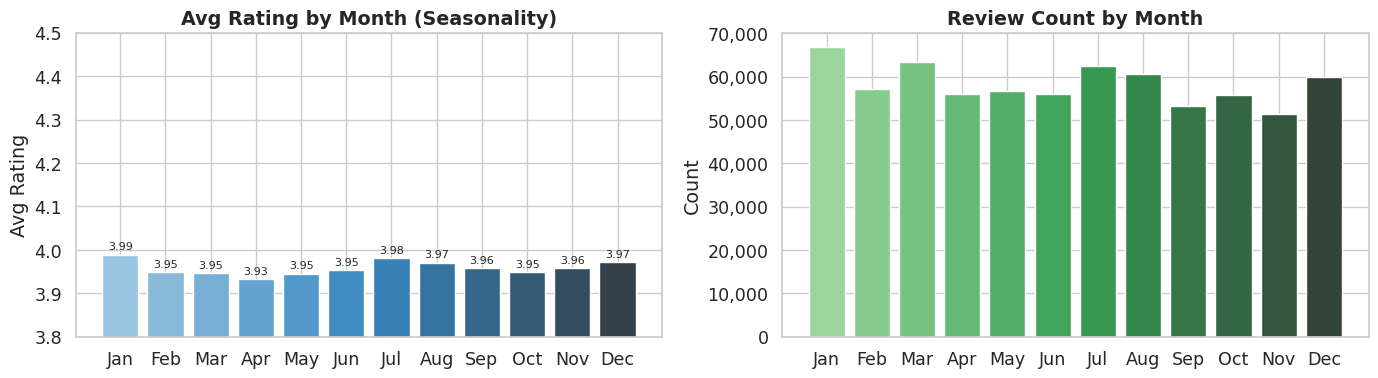

Peak month by volume:       Jan
Lowest avg rating month:    Apr


In [ ]:
# Сезонность: средний рейтинг по месяцу года
seasonality = df.groupby("month")["rating"].agg(["mean", "count", "std"]).reset_index()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(month_names, seasonality["mean"], color=sns.color_palette("Blues_d", 12),
            edgecolor="white")
axes[0].set_title("Avg Rating by Month (Seasonality)", fontweight="bold")
axes[0].set_ylabel("Avg Rating")
axes[0].set_ylim(3.8, 4.5)
axes[0].bar_label(axes[0].containers[0], fmt="%.2f", padding=2, fontsize=8)

axes[1].bar(month_names, seasonality["count"], color=sns.color_palette("Greens_d", 12),
            edgecolor="white")
axes[1].set_title("Review Count by Month", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

# Вывод: пики и провалы
print(f"Peak month by volume:       {month_names[seasonality['count'].idxmax()]}")
print(f"Lowest avg rating month:    {month_names[seasonality['mean'].idxmin()]}")


Выводы: сезонность

**Объем:** январский пик объясняется **post-holiday reviews** -
покупатели оставляют отзывы на подарки, полученные в декабре.
Летний пик (июль) коррелирует с активизацией ухода за кожей
в сезон солнца и отпусков

**Рейтинги:** разброс по месяцам крайне мал - всего **0.06**
(от 3.93 в апреле до 3.99 в январе). Это статистически незначимая
вариация, особенно учитывая объем выборки

для алерт-системы:

> **Сезонность рейтинга несущественна** - разброс 0.06
> не требует сезонной корректировки базовой линии алертов

> **Сезонность объема учитываем:** в январе и июле
> минимальное число отзывов для срабатывания алерта
> (`min_reviews_threshold`) можно немного поднять,
> так как статистической мощности больше

> **Сезонность НЕ является конфаундером** для нашей задачи -
> можно не вводить month как признак в модель



---



**Анализ длины текста**

**Гипотеза (классическая):** негативные отзывы длиннее - люди объясняют проблему

In [ ]:
df["text_len"]   = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df["title_len"]  = df["title"].str.len()
df["has_title"]  = df["title_len"] > 0

# Статистики по классам
text_stats = df.groupby("rating")[["text_len", "word_count"]].agg(
    ["mean", "median", "std", lambda x: np.percentile(x, 90)]
).round(1)
print("Text length statistics by rating:")
print(text_stats)


Text length statistics by rating:
       text_len                              word_count                  \
           mean   median      std <lambda_0>       mean  median     std   
rating                                                                    
1      160.0000 105.0000 196.6000   345.0000    30.3000 20.0000 36.7000   
2      192.9000 125.0000 240.9000   415.0000    36.8000 24.0000 45.2000   
3      204.3000 127.0000 287.0000   440.0000    39.1000 25.0000 52.9000   
4      224.0000 130.0000 315.5000   506.0000    42.7000 25.0000 58.5000   
5      161.3000  91.0000 236.4000   364.0000    30.4000 17.0000 44.1000   

                   
       <lambda_0>  
rating             
1         66.0000  
2         80.0000  
3         84.0000  
4         96.0000  
5         69.0000  


Классическая гипотеза "негативные длиннее" **не подтверждается** на этих данных.

Картина нестандартная:
- **4** - самые развернутые отзывы (mean 224 chars, 42.7 слова): покупатель доволен, но отмечает нюансы
- **5** - самые короткие (median всего 91 char, 17 слов): чистый эмоциональный отклик без объяснений
- **1** короче **2** - наиболее злые отзывы лаконичны

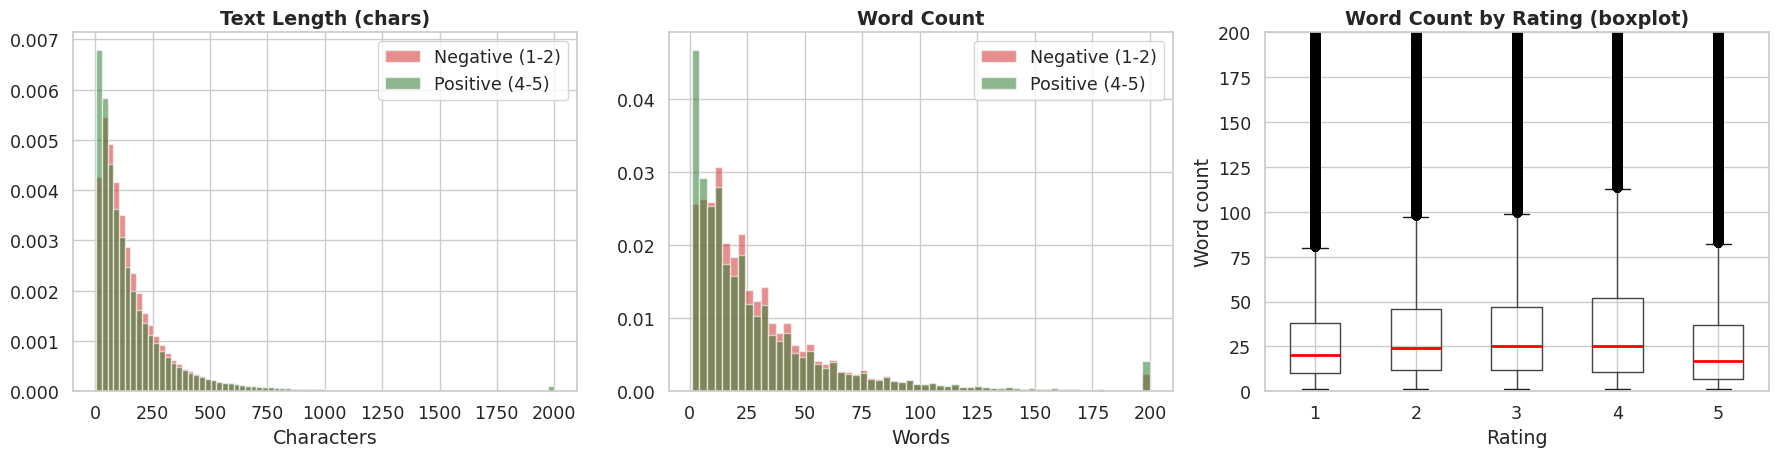

In [ ]:
# KDE: длина текста по классу
df_binary = df[df["rating"] != 3.0].copy()
df_binary["label"] = np.where(df_binary["rating"] <= 2, "Negative (1-2)", "Positive (4-5)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Длина символов
for label, color in [("Negative (1-2)", "#d32f2f"), ("Positive (4-5)", "#2e7d32")]:
    subset = df_binary[df_binary["label"] == label]["text_len"].clip(0, 2000)
    axes[0].hist(subset, bins=80, alpha=0.55, color=color, label=label, density=True)
axes[0].set_title("Text Length (chars)", fontweight="bold")
axes[0].set_xlabel("Characters")
axes[0].legend()

# Кол-во слов
for label, color in [("Negative (1-2)", "#d32f2f"), ("Positive (4-5)", "#2e7d32")]:
    subset = df_binary[df_binary["label"] == label]["word_count"].clip(0, 200)
    axes[1].hist(subset, bins=60, alpha=0.55, color=color, label=label, density=True)
axes[1].set_title("Word Count", fontweight="bold")
axes[1].set_xlabel("Words")
axes[1].legend()

# Boxplot по каждому рейтингу
df.boxplot(column="word_count", by="rating", ax=axes[2],
           boxprops=dict(color="#444"),
           medianprops=dict(color="red", linewidth=2))
axes[2].set_title("Word Count by Rating (boxplot)", fontweight="bold")
axes[2].set_xlabel("Rating")
axes[2].set_ylabel("Word count")
axes[2].set_ylim(0, 200)
plt.suptitle("")

plt.tight_layout()
plt.show()


Распределения негатива и позитива **сильно перекрываются**. Оба класса имеют тяжелый правый хвост. Никакого четкого разделения нет, значит длина текста сама по себе слабый признак для классификации тональности

Медианы всех рейтингов близки (17-25 слов), зато усы длинные -
высокая дисперсия. Это означает, что есть длинные отзывы во всех классах,просто их доля невелика



---



**Выбор max_length токенизатора**

Необходимо определить оптимальный `max_length` для DistilBERT -
баланс между покрытием данных и скоростью обучения

In [ ]:
# Percentile-анализ для выбора max_length токенизатора
from transformers import AutoTokenizer

tokenizer_check = AutoTokenizer.from_pretrained("distilbert-base-uncased")

sample_texts = (df["title"] + " [SEP] " + df["text"]).sample(
    min(50_000, len(df)), random_state=RANDOM_STATE
).tolist()

token_lengths = [
    len(tokenizer_check.encode(t, truncation=False, add_special_tokens=True))
    for t in sample_texts
]

for pct in [50, 75, 90, 95, 99, 100]:
    print(f"  P{pct}: {np.percentile(token_lengths, pct):.0f} tokens")

# Рекомендация
p95 = int(np.percentile(token_lengths, 95))
print(f"\nmax_length = {min(p95 + 16, 256)}")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (616 > 512). Running this sequence through the model will result in indexing errors


  P50: 32 tokens
  P75: 59 tokens
  P90: 102 tokens
  P95: 144 tokens
  P99: 296 tokens
  P100: 3613 tokens

max_length = 160


Распределение **сильно правосторонее (right-skewed):** медиана 32 токена, но хвост уходит до 3613. Значение P100 = 3613 - единичный аномальный сэмпл (например, вставленная инструкция к продукту). Он не влияет на выбор `max_length`

Ключевой ориентир: **P95 = 144 токена**, а с буфером +16 получаем рекомендацию `max_length = 160`. Проверим, одинаково ли это работает для обоих классов

In [ ]:
from transformers import AutoTokenizer
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

if "input_text" not in df_binary.columns:
    df_binary["input_text"] = (
        df_binary["title"].fillna("") + " [SEP] " + df_binary["text"].fillna("")
    ).str.strip()

# Считаем длины по классам
sample = df_binary.sample(min(30_000, len(df_binary)), random_state=42).copy()
sample["token_len"] = sample["input_text"].apply(
    lambda t: len(tokenizer.encode(t, truncation=False, add_special_tokens=True))
)

stats = sample.groupby("label")["token_len"].agg(
    mean=("mean"),
    median=("median"),
    P90=lambda x: np.percentile(x, 90),
    P95=lambda x: np.percentile(x, 95),
    truncated_pct=lambda x: (x > 160).mean() * 100
).round(1)

stats.index = ["Negative (1-2)", "Positive (4-5)"]
print(stats.to_string())

# Финальное решение
neg_trunc = stats.loc["Negative (1-2)", "truncated_pct"]
if neg_trunc < 10:
    max_len = 160
elif neg_trunc < 18:
    max_len = 192
else:
    max_len = 256

print(f"\nNegative truncated at 160: {neg_trunc:.1f}%")

Token indices sequence length is longer than the specified maximum sequence length for this model (1155 > 512). Running this sequence through the model will result in indexing errors


                  mean  median      P90      P95  truncated_pct
Negative (1-2) 48.1000 35.0000  96.0000 126.0000         2.7000
Positive (4-5) 48.5000 30.0000 102.8000 148.0000         4.1000

Negative truncated at 160: 2.7%


При `max_length=160` усечение **симметрично и минимально** для обоих классов

Проверяем весь диапазон разумных значений [64, 96, 128, 160, 192, 256]
по критерию: какой % каждого класса будет усечен

In [ ]:
# Сравним варианты по покрытию
for ml in [64, 96, 128, 160, 192, 256]:
    neg_trunc = (sample[sample["label"] == "Negative (1-2)"]["token_len"] > ml).mean() * 100
    pos_trunc = (sample[sample["label"] == "Positive (4-5)"]["token_len"] > ml).mean() * 100
    coverage  = 100 - max(neg_trunc, pos_trunc)
    print(f"max_length={ml:>3}  |  neg truncated: {neg_trunc:.1f}%  "
          f"|  pos truncated: {pos_trunc:.1f}%  |  coverage: {coverage:.1f}%")


max_length= 64  |  neg truncated: 22.2%  |  pos truncated: 21.4%  |  coverage: 77.8%
max_length= 96  |  neg truncated: 9.8%  |  pos truncated: 11.1%  |  coverage: 88.9%
max_length=128  |  neg truncated: 4.7%  |  pos truncated: 6.7%  |  coverage: 93.3%
max_length=160  |  neg truncated: 2.7%  |  pos truncated: 4.1%  |  coverage: 95.9%
max_length=192  |  neg truncated: 1.7%  |  pos truncated: 2.8%  |  coverage: 97.2%
max_length=256  |  neg truncated: 0.7%  |  pos truncated: 1.5%  |  coverage: 98.5%


- Переход 128->160 дает **+2.6% coverage** при снижении neg_truncation с 4.7% до 2.7% - ощутимый прирост за небольшую цену по времени
- Переход 160->192 даёт лишь **+1.3% coverage** - убывающая отдача

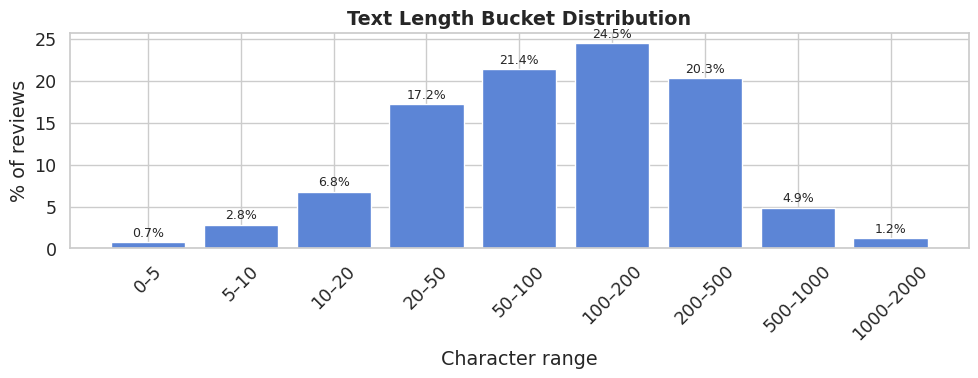

In [ ]:
# Минимальная длина: что дропать?
fig, ax = plt.subplots(figsize=(10, 4))
bins = [0, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]
counts, edges = np.histogram(df["text_len"], bins=bins)

ax.bar(range(len(counts)),
       counts / len(df) * 100,
       tick_label=[f"{bins[i]}–{bins[i+1]}" for i in range(len(bins)-1)],
       color="#5c85d6", edgecolor="white")
ax.set_title("Text Length Bucket Distribution", fontweight="bold")
ax.set_xlabel("Character range")
ax.set_ylabel("% of reviews")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=2, fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Фильтрационный порог: `text_len >= 10`** - убираем 3.5% (0-10 chars). Это минимальная агрессивная фильтрация, которая не затрагивает валидные данные. Порог 20 chars был бы избыточен - убрал бы еще 6.8% реальных отзывов



---



**Анализ активности пользователей и товаров**

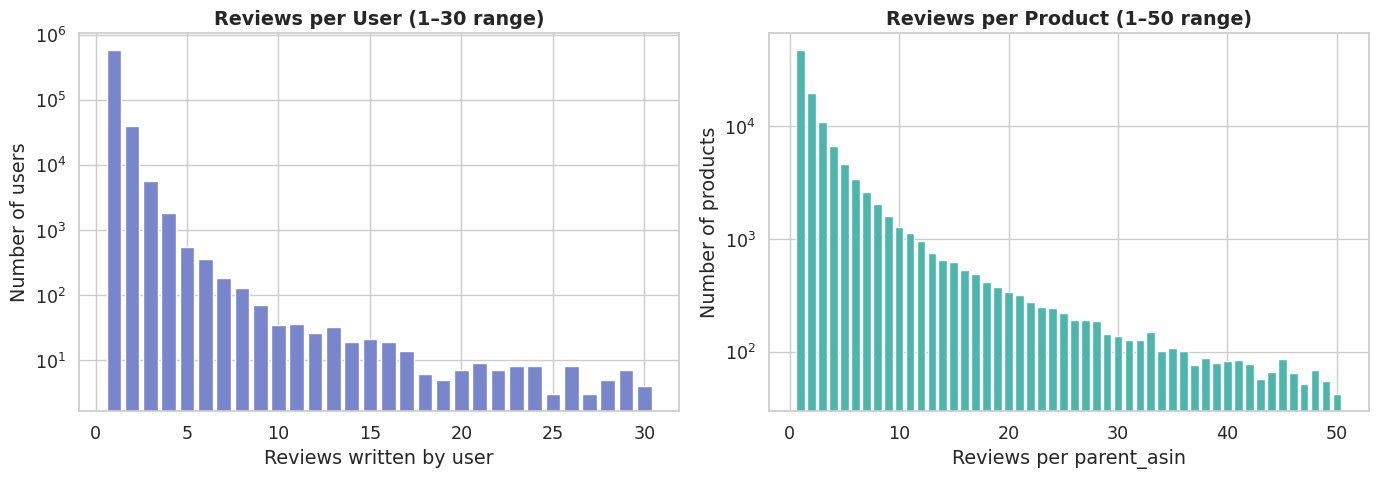

Total unique users:    629,963
Total unique products: 112,381

Users with only 1 review:    92.4%
Products with only 1 review: 42.3%

Top-100 users cover 0.6% of reviews
Top-100 products cover 8.3% of reviews


In [ ]:
# Reviews per user (Power Law)
user_counts = df["user_id"].value_counts()
prod_counts = df["parent_asin"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Users
user_count_dist = user_counts.value_counts().sort_index().head(30)
axes[0].bar(user_count_dist.index, user_count_dist.values, color="#7986cb", edgecolor="white")
axes[0].set_title("Reviews per User (1–30 range)", fontweight="bold")
axes[0].set_xlabel("Reviews written by user")
axes[0].set_ylabel("Number of users")
axes[0].set_yscale("log")

# Products
prod_count_dist = prod_counts.value_counts().sort_index().head(50)
axes[1].bar(prod_count_dist.index, prod_count_dist.values, color="#4db6ac", edgecolor="white")
axes[1].set_title("Reviews per Product (1–50 range)", fontweight="bold")
axes[1].set_xlabel("Reviews per parent_asin")
axes[1].set_ylabel("Number of products")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Total unique users:    {df['user_id'].nunique():,}")
print(f"Total unique products: {df['parent_asin'].nunique():,}")
print(f"\nUsers with only 1 review:    {(user_counts == 1).mean()*100:.1f}%")
print(f"Products with only 1 review: {(prod_counts == 1).mean()*100:.1f}%")
print(f"\nTop-100 users cover {user_counts.head(100).sum() / len(df) * 100:.1f}% of reviews")
print(f"Top-100 products cover {prod_counts.head(100).sum() / len(df) * 100:.1f}% of reviews")


Оба графика демонстрируют строго убывающее Power Law распределение
на log-шкале (прямая линия в log-log = степенной закон).
Это универсальный паттерн для e-commerce платформ

92.4% пользователей написали ровно 1 отзыв - это норма для Amazon:
большинство покупателей оставляют отзыв один раз и больше не возвращаются

Топ-100 самых активных пользователей покрывают лишь **0.6% всех отзывов** - концентрации нет. Это означает:
- Риск **data leakage** при random split минимален
- Накрутка от "профессиональных рецензентов" не доминирует в датасете

42.3% товаров имеют только 1 отзыв - у почти половины продуктов
нет достаточной статистической базы.

Топ-100 товаров покрывают **8.3% всех отзывов** - умеренная концентрация

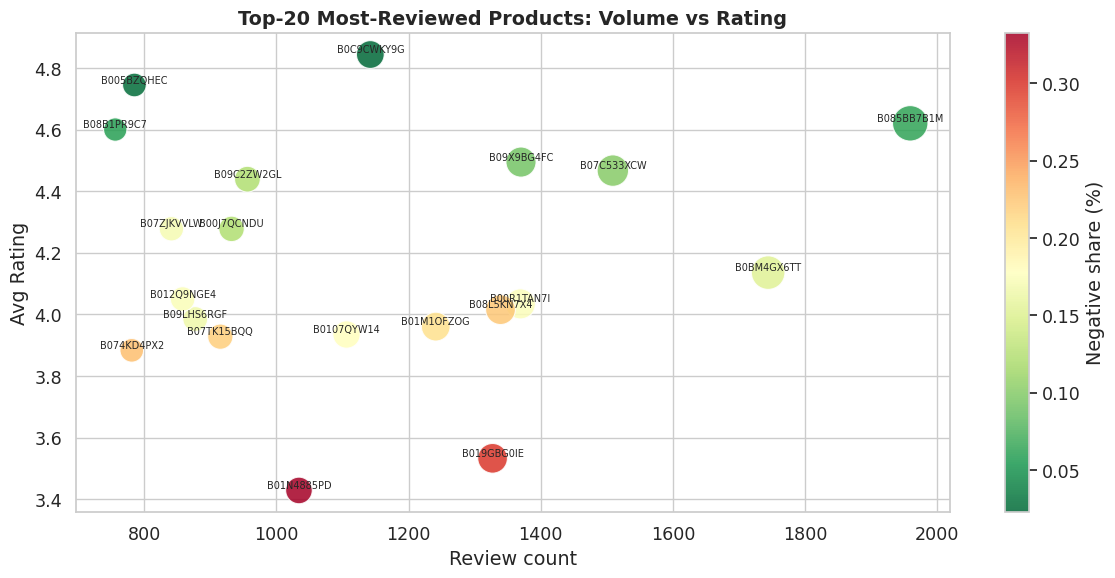

In [ ]:
# Топ-20 товаров: рейтинг и объем
top_products = (
    df.groupby("parent_asin")
    .agg(review_count=("rating", "count"),
         avg_rating=("rating", "mean"),
         neg_share=("rating", lambda x: (x <= 2).mean()))
    .query("review_count >= 100")
    .sort_values("review_count", ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    top_products["review_count"],
    top_products["avg_rating"],
    c=top_products["neg_share"],
    s=top_products["review_count"] / top_products["review_count"].max() * 600 + 50,
    cmap="RdYlGn_r", alpha=0.85, edgecolors="white", linewidths=0.8
)

for _, row in top_products.iterrows():
    ax.annotate(row["parent_asin"][:10], (row["review_count"], row["avg_rating"]),
                fontsize=7, ha="center", va="bottom")

plt.colorbar(scatter, ax=ax, label="Negative share (%)")
ax.set_xlabel("Review count")
ax.set_ylabel("Avg Rating")
ax.set_title("Top-20 Most-Reviewed Products: Volume vs Rating", fontweight="bold")
plt.tight_layout()
plt.show()


Явной линейной зависимости между review count и avg rating нет —
самый популярный товар (`B085BB7B1M`, 2000 отзывов) имеет
rating 4.6, тогда как второй по объёму (`B0BM4GX6TT`, 1750)
— всего 4.1. **Популярность != качество** в beauty-категории



---



Теперь попытаемся выявить лексические паттерны, характерные для негативных и позитивных отзывов. Это даст понимание того, какие сигналы модель должна научиться распознавать

In [ ]:
import string
from sklearn.feature_extraction.text import TfidfVectorizer

EXTRA_STOPS = {
    "product", "use", "used", "one", "get", "like", "really",
    "just", "would", "also", "make", "made", "great", "good",
    "love", "item", "bought", "buy"
}
STOP_WORDS = STOPWORDS | EXTRA_STOPS

def simple_clean(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df_binary["clean"] = (df_binary["title"] + " " + df_binary["text"]).apply(simple_clean)

neg_texts = df_binary[df_binary["label"] == "Negative (1-2)"]["clean"]
pos_texts = df_binary[df_binary["label"] == "Positive (4-5)"]["clean"]

print(f"Negative samples: {len(neg_texts):,}")
print(f"Positive samples: {len(pos_texts):,}")


Negative samples: 144,775
Positive samples: 498,316


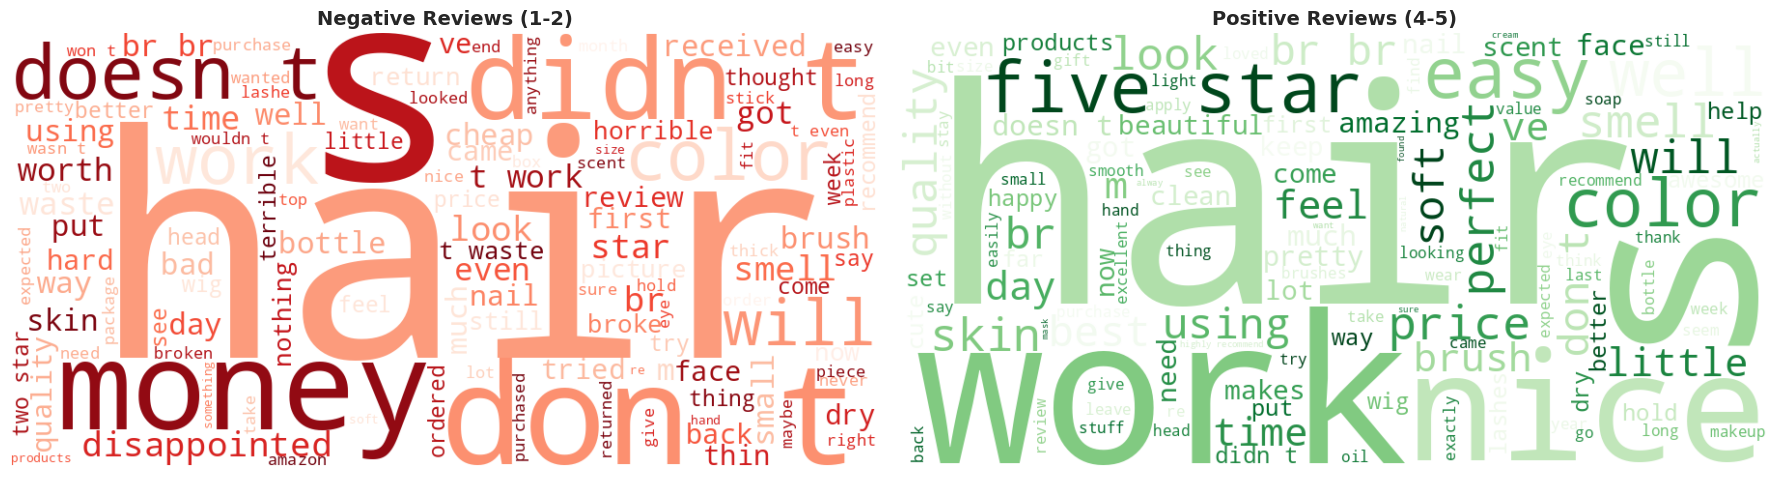

In [ ]:
# WordClouds: негатив vs позитив
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, texts, title, colormap in [
    (axes[0], neg_texts.sample(min(len(neg_texts), 30000), random_state=RANDOM_STATE),
     "Negative Reviews (1-2)", "Reds"),
    (axes[1], pos_texts.sample(min(len(pos_texts), 30000), random_state=RANDOM_STATE),
     "Positive Reviews (4-5)", "Greens")
]:
    corpus = " ".join(texts.tolist())
    wc = WordCloud(
        width=900, height=450, background_color="white",
        stopwords=STOP_WORDS, colormap=colormap,
        max_words=120, collocations=True,
        prefer_horizontal=0.85
    ).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontweight="bold", fontsize=14)

plt.tight_layout()
plt.show()


Два облака **лексически различимы**, но имеют значительное пересечение: `hair`, `work`/`works`, `color`, `brush` присутствуют в обоих классах

Это означает, что **контекст слова критичнее самого слова** — `work`
в позитиве означает "работает", в негативе — часть конструкции "doesn't work". Именно поэтому BiGRU/LSTM проигрывают BERT-моделям на этой задаче: DistilBERT учитывает двунаправленный контекст и корректно интерпретирует отрицание и модальность

WordCloud показал общую картину, но не учитывает **дискриминативность** слов - слово может быть частым в обоих классах и всё равно попасть в топ.

TF-IDF (Term Frequency–Inverse Document Frequency) решает эту проблему: высокий score получают фразы, которые **часты в данном классе, но редки в целом**

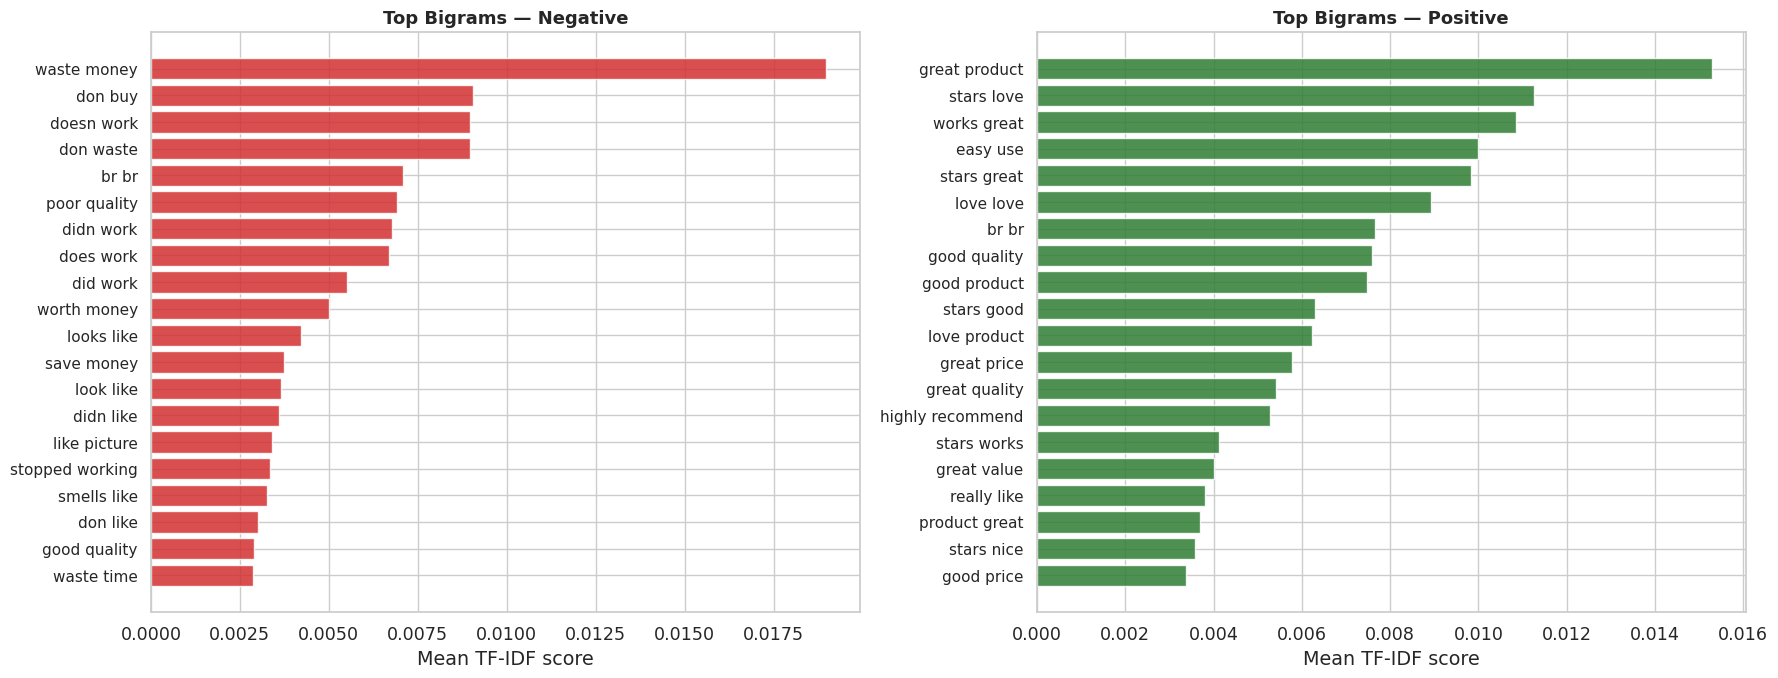

In [ ]:
# TF-IDF топ биграммы по классам
def get_top_ngrams(texts, n=2, top_k=20):
    vec = TfidfVectorizer(
        ngram_range=(n, n), max_features=10_000,
        stop_words="english", min_df=5
    )
    X = vec.fit_transform(texts.sample(min(len(texts), 50_000), random_state=RANDOM_STATE))
    scores = np.asarray(X.mean(axis=0)).flatten()
    vocab = vec.get_feature_names_out()
    top_idx = scores.argsort()[::-1][:top_k]
    return [(vocab[i], scores[i]) for i in top_idx]

neg_bigrams = get_top_ngrams(neg_texts, n=2, top_k=20)
pos_bigrams = get_top_ngrams(pos_texts, n=2, top_k=20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, bigrams, title, color in [
    (axes[0], neg_bigrams, "Top Bigrams — Negative", "#d32f2f"),
    (axes[1], pos_bigrams, "Top Bigrams — Positive", "#2e7d32")
]:
    phrases, scores = zip(*bigrams)
    y_pos = range(len(phrases))
    bars = ax.barh(y_pos, scores, color=color, alpha=0.85, edgecolor="white")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(phrases, fontsize=11)
    ax.set_xlabel("Mean TF-IDF score")
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


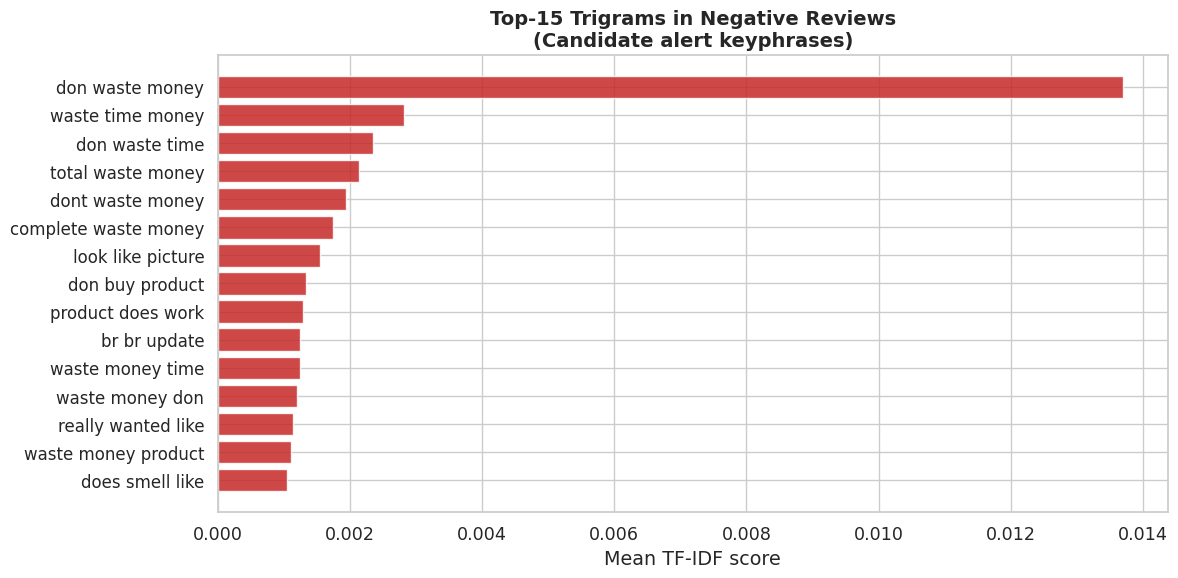

In [ ]:
# Триграммы для причин
neg_trigrams = get_top_ngrams(neg_texts, n=3, top_k=15)

fig, ax = plt.subplots(figsize=(12, 6))
phrases, scores = zip(*neg_trigrams)
y_pos = range(len(phrases))
ax.barh(y_pos, scores, color="#c62828", alpha=0.85, edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(phrases, fontsize=12)
ax.set_xlabel("Mean TF-IDF score")
ax.set_title("Top-15 Trigrams in Negative Reviews\n(Candidate alert keyphrases)",
             fontweight="bold", fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Примечание:** `br br` в обоих классах - артефакт HTML-тегов `<br>` в исходных данных, просочившихся через очистку. Не несет смысловой нагрузки, фильтруем

**Ключевое наблюдение:** 6 из 15 триграмм - вариации фразы "waste money". Это означает, что **финансовое разочарование** - самый частый и эмоционально заряженный тип жалобы в beauty-категории.
Покупатель воспринимает некачественную косметику прежде всего как
потерю денег, а не просто неудобство

`look like picture` - важная отдельная тема: несоответствие
реального товара фотографии на сайте. В алерт-системе это
сигнал о потенциальном **listing fraud** или недобросовестном продавце

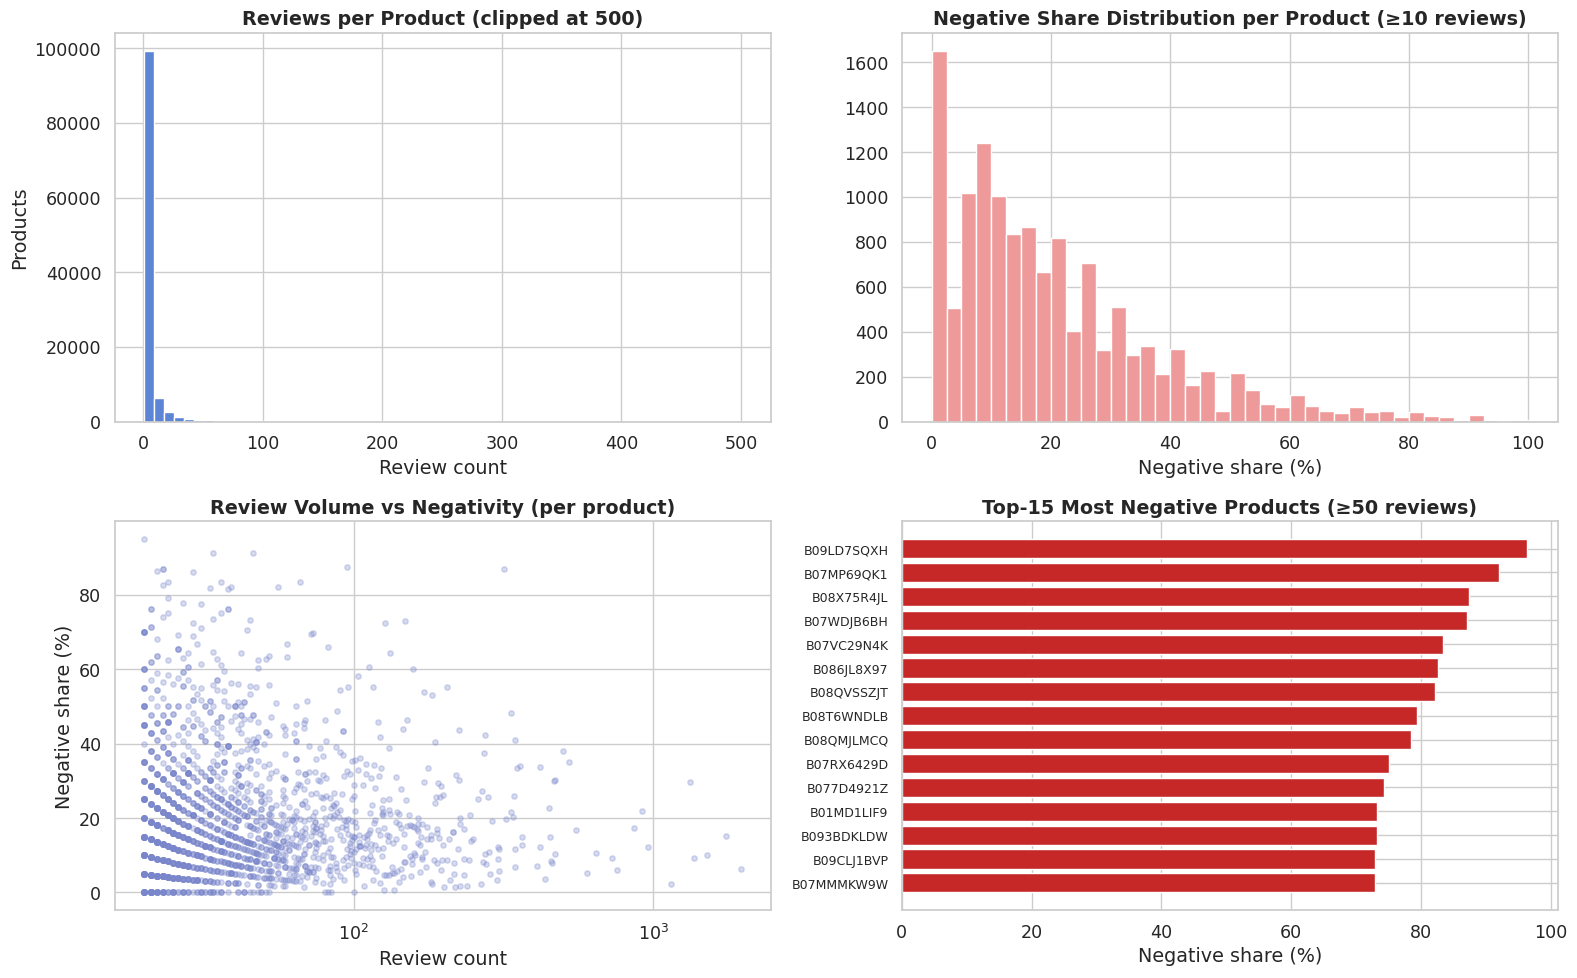

75th percentile product review count: 4


In [ ]:
# Среднее и std рейтинга по товарам
product_stats = (
    df.groupby("parent_asin")
    .agg(
        count=("rating", "count"),
        avg_rating=("rating", "mean"),
        std_rating=("rating", "std"),
        neg_share=("rating", lambda x: (x <= 2).mean()),
        verified_rate=("verified_purchase", "mean")
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Histogram: reviews per product
product_stats["count"].clip(0, 500).hist(bins=60, ax=axes[0,0], color="#5c85d6", edgecolor="white")
axes[0,0].set_title("Reviews per Product (clipped at 500)", fontweight="bold")
axes[0,0].set_xlabel("Review count")
axes[0,0].set_ylabel("Products")

# Histogram: neg_share per product
product_stats[product_stats["count"] >= 10]["neg_share"].mul(100).hist(
    bins=40, ax=axes[0,1], color="#ef9a9a", edgecolor="white")
axes[0,1].set_title("Negative Share Distribution per Product (≥10 reviews)", fontweight="bold")
axes[0,1].set_xlabel("Negative share (%)")

# Scatter: count vs neg_share
sample_prods = product_stats[product_stats["count"] >= 20].sample(min(2000, len(product_stats)))
axes[1,0].scatter(sample_prods["count"], sample_prods["neg_share"] * 100,
                   alpha=0.3, s=15, color="#7986cb")
axes[1,0].set_xlabel("Review count")
axes[1,0].set_ylabel("Negative share (%)")
axes[1,0].set_title("Review Volume vs Negativity (per product)", fontweight="bold")
axes[1,0].set_xscale("log")

# Top-20 "проблемных" товаров
top_neg = (product_stats[product_stats["count"] >= 50]
           .sort_values("neg_share", ascending=False)
           .head(15))
axes[1,1].barh(range(len(top_neg)), top_neg["neg_share"] * 100,
               color="#c62828", edgecolor="white")
axes[1,1].set_yticks(range(len(top_neg)))
axes[1,1].set_yticklabels(top_neg["parent_asin"].str[:12], fontsize=9)
axes[1,1].set_xlabel("Negative share (%)")
axes[1,1].set_title("Top-15 Most Negative Products (≥50 reviews)", fontweight="bold")
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

# Вывод: рекомендуемый порог
p75_reviews = product_stats["count"].quantile(0.75)
print(f"75th percentile product review count: {p75_reviews:.0f}")


75% всех товаров в датасете имеют **4 или меньше отзывов**

Большинство товаров имеют умеренный уровень негатива,
но правый хвост уходит до 100% - это нишевые товары,
которые почти полностью состоят из негативных отзывов

- Товары с <30 отзывами имеют негативные от 0% до 100% - огромная дисперсия
- Товары с >200 отзывами кластеризуются в диапазоне 10-35%
- При >500 отзывах разброс ещё меньше



> Алерт-система будет работать только с топ 25% товаров по объему —
именно там статистика надежна и ложные срабатывания минимальны





---



In [ ]:
RANDOM_STATE   = 42
MAX_LEN        = 160
TRAIN_SIZE     = 0.70   # хронологически первые 70%
VAL_SIZE       = 0.15
TEST_SIZE      = 0.15
UNDERSAMPLE_N  = 50_000  # сэмплов каждого класса в train

SAVE_DIR = Path("data/splits")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df = pd.read_parquet("all_beauty_raw.parquet")

df_binary = df[df["rating"] != 3].copy()
df_binary["label"] = (df_binary["rating"] >= 4).astype(int)
# label: 0 = Negative, 1 = Positive

df_binary["input_text"] = (
    df_binary["title"].fillna("") + " [SEP] " + df_binary["text"].fillna("")
).str.strip()

df_binary = df_binary[df_binary["input_text"].str.len() >= 10].reset_index(drop=True)

print(f"Binary dataset: {len(df_binary):,} rows")
print(f"  Positive (1): {(df_binary['label']==1).sum():,}  "
      f"({(df_binary['label']==1).mean()*100:.1f}%)")
print(f"  Negative (0): {(df_binary['label']==0).sum():,}  "
      f"({(df_binary['label']==0).mean()*100:.1f}%)")

Binary dataset: 644,990 rows
  Positive (1): 499,896  (77.5%)
  Negative (0): 145,094  (22.5%)


In [ ]:
df_binary = df_binary.sort_values("timestamp").reset_index(drop=True)
n = len(df_binary)

train_end = int(n * TRAIN_SIZE)
val_end   = int(n * (TRAIN_SIZE + VAL_SIZE))

train_df = df_binary.iloc[:train_end].copy()
val_df   = df_binary.iloc[train_end:val_end].copy()
test_df  = df_binary.iloc[val_end:].copy()

print("=" * 50)
print(f"{'Split':<8} {'Rows':>8}  {'Date from':<12} {'Date to':<12} {'Neg %':>6}")
print("=" * 50)
for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    neg_pct = (split["label"] == 0).mean() * 100
    print(f"{name:<8} {len(split):>8,}  "
          f"{split['timestamp'].min().date()}  "
          f"{split['timestamp'].max().date()}  {neg_pct:>5.1f}%")

Split        Rows  Date from    Date to       Neg %
train     451,493  2000-11-01  2020-12-05   20.2%
val        96,748  2020-12-05  2021-09-01   26.7%
test       96,749  2021-09-01  2023-09-09   29.0%


In [ ]:
neg_train = train_df[train_df["label"] == 0]
pos_train = train_df[train_df["label"] == 1]

n_samples = min(UNDERSAMPLE_N, len(neg_train), len(pos_train))

train_balanced = pd.concat([
    neg_train.sample(n_samples, random_state=RANDOM_STATE),
    pos_train.sample(n_samples, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Balanced train: {len(train_balanced):,} rows  "
      f"({n_samples:,} neg + {n_samples:,} pos)")
print(f"Val  (no resampling): {len(val_df):,}")
print(f"Test (no resampling): {len(test_df):,}")

COLS = ["input_text", "label", "rating", "timestamp", "parent_asin",
        "asin", "verified_purchase", "helpful_vote"]

train_balanced[COLS].to_parquet(SAVE_DIR / "train.parquet", index=False)
val_df[COLS].to_parquet(SAVE_DIR   / "val.parquet",   index=False)
test_df[COLS].to_parquet(SAVE_DIR  / "test.parquet",  index=False)

Balanced train: 100,000 rows  (50,000 neg + 50,000 pos)
Val  (no resampling): 96,748
Test (no resampling): 96,749


In [ ]:
kafka_df = df.copy()

kafka_df["timestamp"] = kafka_df["timestamp"].dt.strftime("%Y-%m-%dT%H:%M:%S")
kafka_df["review_id"] = [f"rev_{i:07d}" for i in range(len(kafka_df))]

if "input_text" not in kafka_df.columns:
    kafka_df["input_text"] = (
        kafka_df["title"].fillna("") + " [SEP] " + kafka_df["text"].fillna("")
    ).str.strip()

# 3 -> None, потому что в продакшне мы не знаем "правильного" ответа
kafka_df["true_label"] = kafka_df["rating"].map(
    {1: 0, 2: 0, 3: None, 4: 1, 5: 1}
)

KAFKA_COLS = [
    "review_id", "asin", "parent_asin",
    "input_text", "true_label",
    "rating", "timestamp", "verified_purchase", "helpful_vote"
]

kafka_path = Path("data/kafka_stream.jsonl")
with open(kafka_path, "w") as f:
    for _, row in kafka_df[KAFKA_COLS].iterrows():
        f.write(json.dumps(row.to_dict(), default=str) + "\n")

print(f"Kafka stream: {len(kafka_df):,} messages")
print(f"   Negative: {(kafka_df['true_label']==0).sum():,}")
print(f"   Positive: {(kafka_df['true_label']==1).sum():,}")
print(f"   Neutral (3):    {kafka_df['true_label'].isna().sum():,}")

Kafka stream: 701,528 messages
   Negative: 145,114
   Positive: 500,107
   Neutral (3):    56,307




---



## Fine-tuning DistilBERT для классификации тональности

Вход: title [SEP] text -> токены -> [CLS] -> Linear → softmax

Задача: binary classification (0=negative, 1=positive)

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
CFG = {
    "model_name":    "distilbert-base-uncased",
    "num_labels":    2,
    "max_length":    160,

    # Обучение
    "batch_size":    64,
    "epochs":        3,
    "lr":            2e-5,
    "warmup_ratio":  0.1,
    "weight_decay":  0.01,
    "max_grad_norm": 1.0,

    "class_weights": [1.60, 0.40],   # [neg_weight, pos_weight]

    # Early stopping
    "patience":      2,
    "monitor":       "val_f1_neg",

    # Пути
    "data_dir":      Path("data/splits"),
    "model_dir":     Path("model/sentiment_distilbert"),
    "random_state":  42,
}
CFG["model_dir"].mkdir(parents=True, exist_ok=True)
torch.manual_seed(CFG["random_state"])
np.random.seed(CFG["random_state"])

In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int):
        self.texts  = df["input_text"].tolist()
        self.labels = df["label"].tolist()
        self.tok    = tokenizer
        self.max_len = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"])

train_df = pd.read_parquet(CFG["data_dir"] / "train.parquet")
val_df   = pd.read_parquet(CFG["data_dir"] / "val.parquet")
test_df  = pd.read_parquet(CFG["data_dir"] / "test.parquet")

train_ds = ReviewDataset(train_df, tokenizer, CFG["max_length"])
val_ds   = ReviewDataset(val_df,   tokenizer, CFG["max_length"])
test_ds  = ReviewDataset(test_df,  tokenizer, CFG["max_length"])

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"] * 2,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"] * 2,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader):,}  "
      f"| Val: {len(val_loader):,}  "
      f"| Test: {len(test_loader):,}")

Train batches: 1,563  | Val: 756  | Test: 756


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    CFG["model_name"], num_labels=CFG["num_labels"]
).to(DEVICE)

# Weighted loss - компенсируем дисбаланс на val/test данных
weights = torch.tensor(CFG["class_weights"], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = AdamW(model.parameters(),
                  lr=CFG["lr"],
                  weight_decay=CFG["weight_decay"])

total_steps   = len(train_loader) * CFG["epochs"]
warmup_steps  = int(total_steps * CFG["warmup_ratio"])
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {train_params:,}")
print(f"Total steps:      {total_steps:,}  |  Warmup: {warmup_steps:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params:     66,955,010
Trainable params: 66,955,010
Total steps:      4,689  |  Warmup: 468


In [ ]:
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, scheduler, criterion, epoch, total_epochs):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    pbar = tqdm(
        loader,
        desc=f"Epoch {epoch}/{total_epochs} [Train]",
        leave=False,
        dynamic_ncols=True,
    )

    for step, batch in enumerate(pbar, 1):
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attn_mask).logits
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["max_grad_norm"])
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Обновляем постфикс каждые 50 шагов
        if step % 50 == 0:
            running_loss = total_loss / step
            running_f1   = f1_score(all_labels, all_preds,
                                    pos_label=0, average="binary",
                                    zero_division=0)
            pbar.set_postfix({
                "loss": f"{running_loss:.4f}",
                "f1_neg": f"{running_f1:.4f}",
                "lr": f"{scheduler.get_last_lr()[0]:.2e}",
            })

    avg_loss = total_loss / len(loader)
    f1_neg   = f1_score(all_labels, all_preds, pos_label=0, average="binary")
    f1_mac   = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, f1_neg, f1_mac


@torch.no_grad()
def eval_epoch(model, loader, criterion, desc="Val"):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    pbar = tqdm(loader, desc=f"           [{desc}]",
                leave=False, dynamic_ncols=True)

    for batch in pbar:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)

        logits = model(input_ids=input_ids, attention_mask=attn_mask).logits
        loss   = criterion(logits, labels)

        total_loss += loss.item()
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1_neg   = f1_score(all_labels, all_preds, pos_label=0, average="binary")
    f1_mac   = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, f1_neg, f1_mac, all_preds, all_labels

In [ ]:
history = {"train_loss": [], "val_loss": [],
           "train_f1_neg": [], "val_f1_neg": [],
           "train_f1_mac": [], "val_f1_mac": []}

best_val_f1  = 0.0
patience_cnt = 0

# Внешний прогресс-бар по эпохам
epoch_pbar = tqdm(
    range(1, CFG["epochs"] + 1),
    desc="Training",
    unit="epoch",
    dynamic_ncols=True,
)

for epoch in epoch_pbar:
    tr_loss, tr_f1n, tr_f1m = train_epoch(
        model, train_loader, optimizer, scheduler, criterion,
        epoch, CFG["epochs"]
    )
    vl_loss, vl_f1n, vl_f1m, _, _ = eval_epoch(
        model, val_loader, criterion, desc="Val"
    )

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_f1_neg"].append(tr_f1n)
    history["val_f1_neg"].append(vl_f1n)
    history["train_f1_mac"].append(tr_f1m)
    history["val_f1_mac"].append(vl_f1m)

    epoch_pbar.set_postfix({
        "tr_loss": f"{tr_loss:.4f}",
        "vl_loss": f"{vl_loss:.4f}",
        "vl_f1n":  f"{vl_f1n:.4f}",
        "best":    f"{best_val_f1:.4f}",
    })

    tqdm.write(
        f"Epoch {epoch:02d}  |  "
        f"train loss={tr_loss:.4f}  f1_neg={tr_f1n:.4f}  f1_mac={tr_f1m:.4f}  |  "
        f"val   loss={vl_loss:.4f}  f1_neg={vl_f1n:.4f}  f1_mac={vl_f1m:.4f}"
    )

    if vl_f1n > best_val_f1:
        best_val_f1  = vl_f1n
        patience_cnt = 0
        model.save_pretrained(CFG["model_dir"])
        tokenizer.save_pretrained(CFG["model_dir"])
        tqdm.write(f"  New best val_f1_neg={best_val_f1:.4f} → model saved")
    else:
        patience_cnt += 1
        tqdm.write(f"  No improvement ({patience_cnt}/{CFG['patience']})")
        if patience_cnt >= CFG["patience"]:
            tqdm.write("  Early stopping triggered")
            break

tqdm.write(f"\nTraining complete. Best val_f1_neg: {best_val_f1:.4f}")

Training:   0%|          | 0/3 [00:00<?, ?epoch/s]

Epoch 1/3 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

           [Val]:   0%|          | 0/756 [00:00<?, ?it/s]

Epoch 01  |  train loss=0.1234  f1_neg=0.9202  f1_mac=0.9149  |  val   loss=0.1100  f1_neg=0.9155  f1_mac=0.9407


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

           [Val]:   0%|          | 0/756 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d8f88b4e7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^Exception ignored in: ^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'<function _MultiProcessingDataLoaderIter.__del__ at 0x7d8f88b4e7a0>

 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
       self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive():  
  ^ ^ ^ ^ ^^  ^^^^^^^^^^^^^^^^^^^

Epoch 03  |  train loss=0.0337  f1_neg=0.9859  f1_mac=0.9858  |  val   loss=0.1140  f1_neg=0.9281  f1_mac=0.9499


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best val_f1_neg=0.9281 → model saved

Training complete. Best val_f1_neg: 0.9281


## Результаты обучения модели

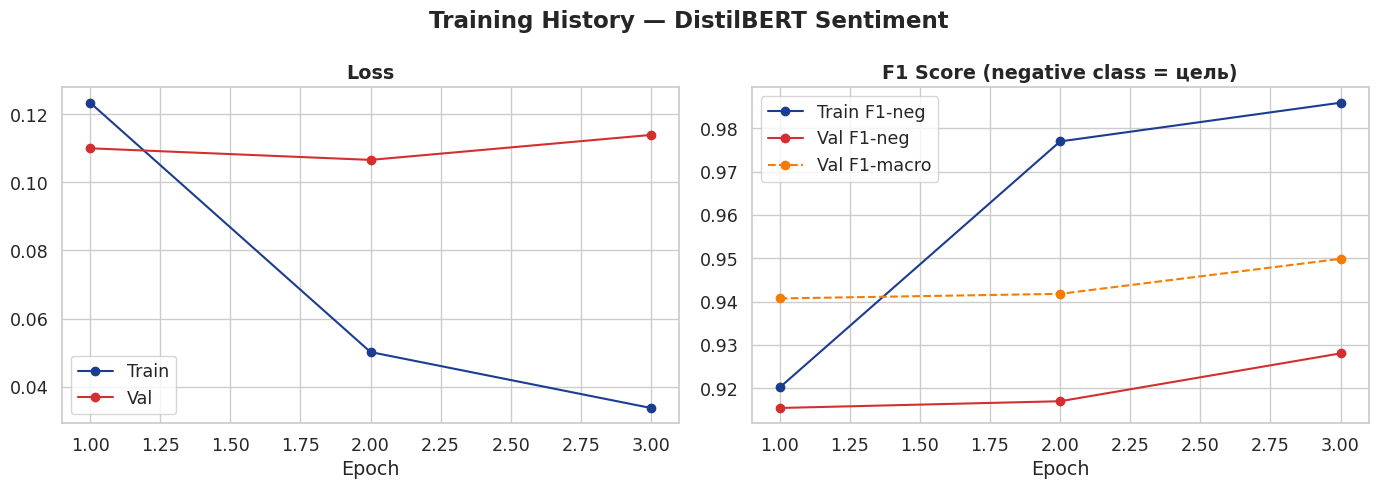

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_ran, history["train_loss"], "o-", label="Train", color="#1a3d8f")
axes[0].plot(epochs_ran, history["val_loss"],   "o-", label="Val",   color="#d32f2f")
axes[0].set_title("Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_ran, history["train_f1_neg"], "o-", label="Train F1-neg", color="#1a3d8f")
axes[1].plot(epochs_ran, history["val_f1_neg"],   "o-", label="Val F1-neg",   color="#d32f2f")
axes[1].plot(epochs_ran, history["val_f1_mac"],   "o--",label="Val F1-macro", color="#f57c00")
axes[1].set_title("F1 Score (negative class = цель)", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle("Training History — DistilBERT Sentiment", fontweight="bold")
plt.tight_layout()
plt.show()

Train loss уверенно снижается с 0.123 до 0.035, демонстрируя стабильную сходимость модели. Val loss при этом почти не меняется (0.109 => 0.106 => 0.115) - небольшой рост на 3-й эпохе является первым сигналом легкого переобучения. Это ожидаемое поведение: балансированный train-сплит (50k neg / 50k pos) отличается от val-выборки с реальным распределением 73/27%, поэтому разрыв между кривыми структурно обоснован, а не является критической проблемой

Также по правому графику train F1-neg резко вырастает с 0.921 до 0.985, тогда как Val F1-neg растет медленнее: 0.915 => 0.917 => 0.929. Такой разрыв объясняется distribution shift: тренировочная выборка охватывает период 2000-2020, а валидационная - декабрь 2020-сентябрь 2021, когда доля негативных отзывов выросла с примерно 20% до примерно 27%. Val F1-macro стабильно растет с 0.940 до 0.950, подтверждая, что модель улучшается на обоих классах

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

           [Val]:   0%|          | 0/756 [00:00<?, ?it/s]

              precision    recall  f1-score   support

Negative (0)     0.8712    0.9815    0.9231     28038
Positive (1)     0.9921    0.9408    0.9657     68711

    accuracy                         0.9526     96749
   macro avg     0.9316    0.9612    0.9444     96749
weighted avg     0.9570    0.9526    0.9534     96749



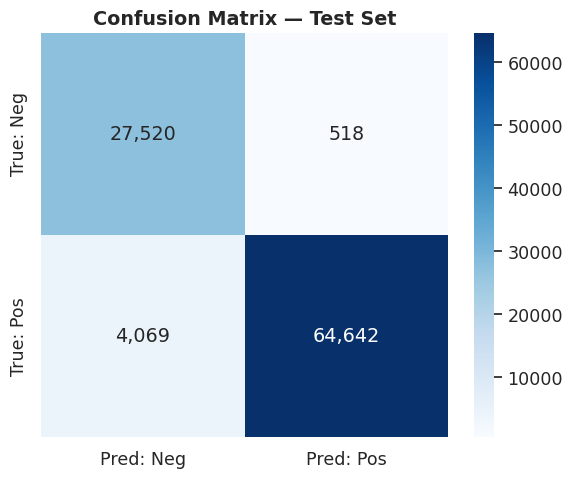

In [ ]:
best_model = AutoModelForSequenceClassification.from_pretrained(
    CFG["model_dir"]
).to(DEVICE)

_, _, _, test_preds, test_labels = eval_epoch(
    best_model, test_loader, criterion
)

print(classification_report(
    test_labels, test_preds,
    target_names=["Negative (0)", "Positive (1)"],
    digits=4
))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
            xticklabels=["Pred: Neg", "Pred: Pos"],
            yticklabels=["True: Neg", "True: Pos"])
ax.set_title("Confusion Matrix — Test Set", fontweight="bold")
plt.tight_layout()
plt.show()

Модель достигает accuracy 95.3% на тестовом сете (96,749 примеров, период 2021-2023). Главный акцент: recall негативного класса = 98.2%: из 28,038 реально негативных отзывов пропущено лишь 518 (FN), что на самом деле важно для алерт-системы, где пропуск жалобы дороже ложной тревоги. Обратная сторона - precision негатива = 87.1%: 4,069 позитивных отзывов ошибочно размечены как негативные (FP), что допустимо в продакшне, так как ложные алерты легче фильтровать вторым уровнем, чем восстанавливать пропущенные сигналы о качестве

In [ ]:
def predict(texts: list[str], model, tokenizer,
            max_len=160, batch_size=32) -> list[dict]:
    """
    Входной формат: список строк 'title [SEP] text'
    Возвращает: список {label, prob_neg, prob_pos}
    """
    model.eval()
    results = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        enc = tokenizer(
            batch_texts, max_length=max_len,
            padding=True, truncation=True, return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        for p in probs:
            results.append({
                "label":    int(p.argmax()),
                "prob_neg": round(float(p[0]), 4),
                "prob_pos": round(float(p[1]), 4),
            })
    return results


# Тест на живых примерах
test_texts = [
    "Terrible product [SEP] Complete waste of money. Caused a skin rash. Returned immediately.",
    "Great moisturizer [SEP] Love this product! My skin feels so soft and hydrated every day.",
    "Okay but overpriced [SEP] Works fine but nothing special for this price point.",
]

preds = predict(test_texts, best_model, tokenizer)
for text, pred in zip(test_texts, preds):
    label_str = "NEGATIVE" if pred["label"] == 0 else "POSITIVE"
    print(f"{label_str}  prob_neg={pred['prob_neg']:.3f}  "
          f"prob_pos={pred['prob_pos']:.3f}")

NEGATIVE  prob_neg=1.000  prob_pos=0.000
POSITIVE  prob_neg=0.003  prob_pos=0.997
NEGATIVE  prob_neg=0.883  prob_pos=0.117


Можно подтвердить, что модель отлично работает на негативных и позитивных отзывах

In [ ]:
import json

inference_cfg = {
    "model_path":    str(CFG["model_dir"]),
    "max_length":    CFG["max_length"],
    "input_format":  "title [SEP] text",
    "labels":        {0: "negative", 1: "positive"},
    "threshold_neg": 0.5,
    "alert_threshold": 0.7,

    # Параметры алерт-логики для Consumer 2
    "min_reviews_window":   20,
    "min_reviews_baseline": 50,
    "alert_z_threshold":    3.0,
    "window_hours":         24,
}

with open(CFG["model_dir"] / "inference_config.json", "w") as f:
    json.dump(inference_cfg, f, indent=2)

print(json.dumps(inference_cfg, indent=2))

{
  "model_path": "model/sentiment_distilbert",
  "max_length": 160,
  "input_format": "title [SEP] text",
  "labels": {
    "0": "negative",
    "1": "positive"
  },
  "threshold_neg": 0.5,
  "alert_threshold": 0.7,
  "min_reviews_window": 20,
  "min_reviews_baseline": 50,
  "alert_z_threshold": 3.0,
  "window_hours": 24
}


In [ ]:
!cd /content && zip -r all_without_some_data.zip . -x "sample_data/*" ".config/*" "all_beauty_raw.parquet" "all_beauty_meta.parquet"


  adding: plots/ (stored 0%)
  adding: .ipynb_checkpoints/ (stored 0%)
  adding: data/ (stored 0%)
  adding: data/splits/ (stored 0%)
  adding: data/splits/val.parquet (deflated 13%)
  adding: data/splits/train.parquet (deflated 12%)
  adding: data/splits/test.parquet (deflated 13%)
  adding: data/kafka_stream.jsonl (deflated 73%)
  adding: model/ (stored 0%)
  adding: model/sentiment_distilbert/ (stored 0%)
  adding: model/sentiment_distilbert/config.json (deflated 48%)
  adding: model/sentiment_distilbert/tokenizer_config.json (deflated 42%)
  adding: model/sentiment_distilbert/tokenizer.json (deflated 71%)
  adding: model/sentiment_distilbert/inference_config.json (deflated 40%)
  adding: model/sentiment_distilbert/model.safetensors (deflated 8%)


In [ ]:
from google.colab import files
files.download("/content/all_without_some_data.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



---

